# 07 · LSTM เทียบกับ Ridge / LightGBM (หัวข้อ 4.2 ในข้อเสนอโครงงาน)

ข้อเสนอโครงงานคาดว่า LSTM จะ "จับรูปแบบการเปลี่ยนแปลงและ Lag Time ของมวลน้ำได้ดีกว่าต้นไม้ตัดสินใจ"
notebook นี้ทดสอบข้อสันนิษฐานนั้นด้วยข้อมูลจริง บนโจทย์และชุดทดสอบเดียวกับ notebook 04 และ 06

**สถาปัตยกรรม** (`mojito/lstm.py`)
```
ข้อมูลย้อนหลัง 30 วัน × 46 features ──► LSTM (hidden 32–64) ──┐
                                                               ├──► MLP ──► การเปลี่ยนแปลงระดับน้ำ h = 1…5 (พร้อมกัน)
พยากรณ์ฝน t+1…t+h (5 ค่า, ถ้าใช้) ─────────────────────────────┘
```
- ทำนาย **การเปลี่ยนแปลง** จากระดับวันนี้ เหมือนโมเดลอื่น (จึงทำนายเกินช่วง train ได้)
- loss = MSE ที่ให้น้ำหนักวันน้ำสูง (≥ 3 ม.) มากขึ้น เพราะเป็นวันที่หายากแต่สำคัญที่สุด
- ข้อมูลน้อย (~1,400 ลำดับ) ผลแต่ละ seed แกว่ง → เฉลี่ย 5 seed (ensemble)
- แบบใช้พยากรณ์ฝน: เทรนด้วยฝน ERA5 จริง ทดสอบด้วยพยากรณ์ GFS ปรับ bias — แนวทางเดียวกับ notebook 06

**ขั้นตอน:** เลือก hyperparameter + จำนวน epoch ด้วย validation (มี.ค.–ธ.ค. 2024) → เทรนใหม่บน 2020–2024 ด้วยจำนวน epoch นั้น → วัดบน test ครั้งเดียว

In [1]:
import itertools
import time
import warnings

import matplotlib.pyplot as plt
import numpy
import pandas
import torch
from IPython.display import display

from mojito import config, evaluation, features, lstm, models

warnings.filterwarnings("ignore", category=UserWarning)
torch.set_num_threads(6)
plt.rcParams.update({
    "font.family": ["Noto Sans Thai", "DejaVu Sans"],
    "figure.figsize": (12, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
HORIZONS = features.HORIZONS
SEEDS = range(5)
BEST_TABULAR = {"ridge_delta": {"alpha": 1}, "lgbm_delta": {"num_leaves": 7, "min_child_samples": 10}}  # notebook 04

table = pandas.read_parquet(config.DATA_DIR / "processed" / "features_daily.parquet")
rain_setup = models.load_manifest("x44_ridge_delta_nwp")["extra"]["rain"]
nwp_daily = features.nwp_daily_rain(pandas.read_parquet(config.RAW_DIR / "nwp_rain_previous_runs.parquet"))
for model in rain_setup["nwp_models"]:
    table = features.add_forecast_rain(table, nwp_daily, model)
table = features.combine_forecast_rain(table, rain_setup)  # rain_next{h}d = พยากรณ์ GFS ปรับ bias

FEATURES = features.feature_columns(table)
RAIN = [f"rain_next{h}d" for h in HORIZONS]
# perfect prognosis: training sees the rain that actually fell
oracle_table = table.assign(**{f"rain_next{h}d": table[f"oracle_rain_next{h}d"] for h in HORIZONS})

train_days = table.index[table["split"] == "train"]
validation_days = table.index[(table["split"] == "validation") & table["rain_next5d"].notna()]
train_validation_days = table.index[table["split"] != "test"]
test_days = table.index[table["split"] == "test"]
print(f"ลำดับ train {len(train_days)} วัน · validation {len(validation_days)} · test {len(test_days)}")

ลำดับ train 1418 วัน · validation 307 · test 642


## 1 · เลือก hyperparameter ด้วย validation
grid เล็ก (ข้อมูลน้อย): ขนาด hidden, dropout, learning rate, น้ำหนักวันน้ำสูงใน loss
แต่ละชุดเฉลี่ย 3 seed และ early stopping บน validation (ฝนใน validation = พยากรณ์จริง)

In [2]:
GRID = [
    {"hidden": 64, "dropout": 0.2, "lr": 1e-3, "high_water_weight": 4.0},
    {"hidden": 32, "dropout": 0.3, "lr": 1e-3, "high_water_weight": 4.0},
    {"hidden": 64, "dropout": 0.2, "lr": 3e-4, "high_water_weight": 4.0},
    {"hidden": 64, "dropout": 0.2, "lr": 1e-3, "high_water_weight": 0.0},
]
VARIANTS = {"LSTM": [], "LSTM + พยากรณ์ฝน": RAIN}


def lstm_ensemble(params, rain_columns, fit_table, fit_days, predict_days, epochs, validate=False, seeds=SEEDS):
    """Average of several seeds; returns (predictions, best epochs, curves)."""
    predictions, best_epochs, curves = [], [], []
    for seed in seeds:
        model = lstm.LSTMForecaster(FEATURES, rain_columns, seed=seed, **params)
        if validate:
            model.fit(fit_table, fit_days, epochs=epochs, validation_table=table, validation_days=validation_days)
            best_epochs.append(model.best_epoch)
            curves.append(model.history)
        else:
            model.fit(fit_table, fit_days, epochs=epochs)
        predictions.append(model.predict(table, predict_days))
    return sum(predictions) / len(predictions), best_epochs, curves


tuning, CURVES = [], {}
for (variant, rain_columns), params in itertools.product(VARIANTS.items(), GRID):
    fit_table = oracle_table if rain_columns else table
    prediction, best_epochs, curves = lstm_ensemble(
        params, rain_columns, fit_table, train_days, validation_days, epochs=80, validate=True, seeds=range(3))
    frame = table.loc[validation_days]
    per_h = [evaluation.scores(prediction[f"h{h}"], frame, h) for h in HORIZONS]
    tuning.append({
        "variant": variant, **params,
        "epochs": int(numpy.median(best_epochs)),
        "MAE วันน้ำหลาก (เฉลี่ย h)": numpy.mean([s["MAE วันน้ำหลาก"] for s in per_h]),
        "MAE ทุกวัน (เฉลี่ย h)": numpy.mean([s["MAE ทุกวัน"] for s in per_h]),
    })
    CURVES[(variant, tuple(params.values()))] = curves
tuning = pandas.DataFrame(tuning)
display(tuning.round({"MAE วันน้ำหลาก (เฉลี่ย h)": 3, "MAE ทุกวัน (เฉลี่ย h)": 3}))

BEST = {
    variant: rows.loc[rows["MAE วันน้ำหลาก (เฉลี่ย h)"].idxmin()]
    for variant, rows in tuning.groupby("variant")
}
for variant, row in BEST.items():
    print(f"{variant}: hidden={row.hidden}, dropout={row.dropout}, lr={row.lr}, weight={row.high_water_weight}, epochs={row.epochs}")

,variant,hidden,dropout,lr,high_water_weight,epochs,MAE วันน้ำหลาก (เฉลี่ย h),MAE ทุกวัน (เฉลี่ย h)
0,LSTM,64,0.2,0.0010,4.0,7,2.198,0.484
1,LSTM,32,0.3,0.0010,4.0,15,2.108,0.498
2,LSTM,64,0.2,0.0003,4.0,20,2.182,0.507
3,LSTM,64,0.2,0.0010,0.0,5,2.707,0.373
4,LSTM + พยากรณ์ฝน,64,0.2,0.0010,4.0,11,2.120,0.418
5,LSTM + พยากรณ์ฝน,32,0.3,0.0010,4.0,18,2.188,0.418
6,LSTM + พยากรณ์ฝน,64,0.2,0.0003,4.0,22,2.053,0.449
7,LSTM + พยากรณ์ฝน,64,0.2,0.0010,0.0,7,2.478,0.375


LSTM: hidden=32, dropout=0.3, lr=0.001, weight=4.0, epochs=15
LSTM + พยากรณ์ฝน: hidden=64, dropout=0.2, lr=0.0003, weight=4.0, epochs=22


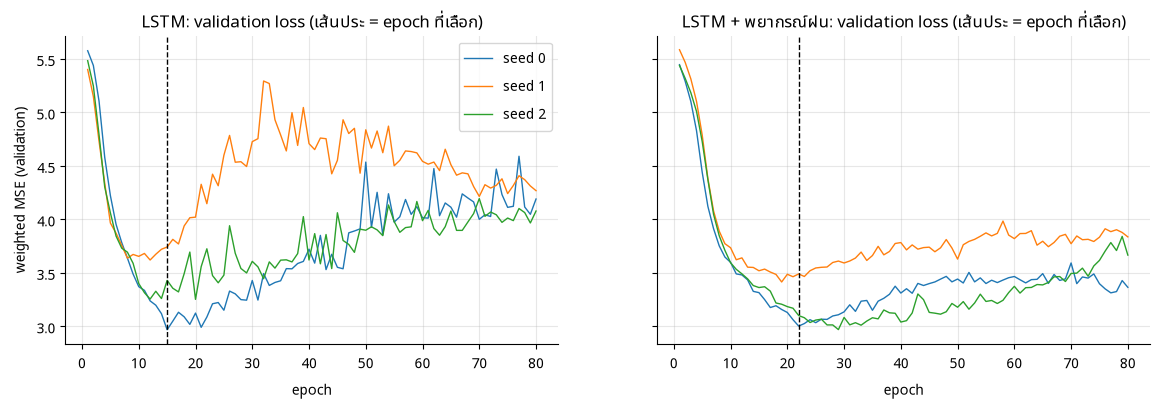

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, (variant, row) in zip(axes, BEST.items()):
    key = (variant, (row.hidden, row.dropout, row.lr, row.high_water_weight))
    for seed, curve in enumerate(CURVES[key]):
        ax.plot(range(1, len(curve) + 1), curve, lw=1, label=f"seed {seed}")
    ax.axvline(row.epochs, color="k", ls="--", lw=1)
    ax.set_title(f"{variant}: validation loss (เส้นประ = epoch ที่เลือก)")
    ax.set_xlabel("epoch")
axes[0].set_ylabel("weighted MSE (validation)")
axes[0].legend()
plt.show()

validation loss ต่ำสุดเร็วมาก (ไม่กี่สิบ epoch) แล้วเพิ่มขึ้น = **overfit เร็ว** เพราะข้อมูลมีน้อยและวันน้ำหลากใน train มีไม่กี่วัน

## 2 · ผลบน test (2025–2026)
ทุกโมเดลเทรนบน 2020–2024 · LSTM ใช้จำนวน epoch จาก validation และเฉลี่ย 5 seed · จับเวลาเทรนด้วย

In [4]:
results, predictions, train_seconds = [], {}, {}
fit_table = table[table["split"] != "test"]
fit_oracle = oracle_table[oracle_table["split"] != "test"]
test = table.loc[test_days]

# Tabular models: one model per horizon
for name, params in BEST_TABULAR.items():
    for use_rain in (False, True):
        label = f"{name}{' + พยากรณ์ฝน' if use_rain else ''}"
        start = time.perf_counter()
        for h in HORIZONS:
            feature_names = FEATURES + ([f"rain_next{h}d"] if use_rain else [])
            model = models.HorizonModel(name, h, feature_names, params).fit(fit_oracle if use_rain else fit_table)
            predictions[(label, h)] = model.predict(test)
        train_seconds[label] = time.perf_counter() - start

# LSTM ensembles
for variant, row in BEST.items():
    params = {"hidden": int(row.hidden), "dropout": row.dropout, "lr": row.lr, "high_water_weight": row.high_water_weight}
    rain_columns = VARIANTS[variant]
    start = time.perf_counter()
    prediction, _, _ = lstm_ensemble(params, rain_columns, oracle_table if rain_columns else table,
                                     train_validation_days, test_days, epochs=int(row.epochs))
    train_seconds[variant] = time.perf_counter() - start
    for h in HORIZONS:
        predictions[(variant, h)] = prediction[f"h{h}"].reindex(test_days)

for h in HORIZONS:
    predictions[("persistence", h)] = evaluation.persistence(test, h)

ORDER = ["persistence", "ridge_delta", "lgbm_delta", "LSTM", "ridge_delta + พยากรณ์ฝน", "lgbm_delta + พยากรณ์ฝน", "LSTM + พยากรณ์ฝน"]
results = pandas.DataFrame([
    {"model": name, "h": h, **evaluation.scores(predictions[(name, h)], test, h)}
    for name in ORDER for h in HORIZONS
])
for metric in ["MAE วันน้ำหลาก", "MAE ทุกวัน"]:
    display(results.pivot(index="model", columns="h", values=metric).loc[ORDER].round(2)
            .rename_axis(columns=f"{metric} (ม.) · h ="))

MAE วันน้ำหลาก (ม.) · h =,1,2,3,4,5
model,,,,,
persistence,1.35,2.51,3.61,4.24,4.78
ridge_delta,0.68,1.65,3.06,4.14,4.73
lgbm_delta,0.86,1.87,3.36,4.49,5.18
LSTM,1.27,2.43,3.34,4.08,4.45
ridge_delta + พยากรณ์ฝน,0.80,1.47,2.33,3.10,3.63
lgbm_delta + พยากรณ์ฝน,1.10,1.59,2.51,3.37,3.80
LSTM + พยากรณ์ฝน,0.92,1.58,2.51,3.16,3.47


MAE ทุกวัน (ม.) · h =,1,2,3,4,5
model,,,,,
persistence,0.14,0.22,0.28,0.32,0.35
ridge_delta,0.10,0.17,0.25,0.31,0.35
lgbm_delta,0.11,0.19,0.25,0.30,0.34
LSTM,0.20,0.33,0.42,0.49,0.54
ridge_delta + พยากรณ์ฝน,0.11,0.17,0.23,0.29,0.32
lgbm_delta + พยากรณ์ฝน,0.11,0.18,0.23,0.28,0.31
LSTM + พยากรณ์ฝน,0.15,0.24,0.31,0.36,0.41


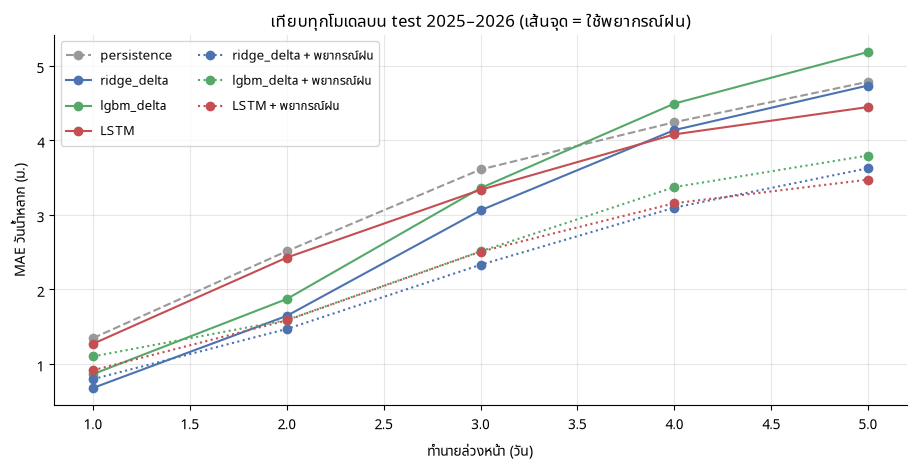

วันที่ระดับจริง ≥ 7.4 ม. ในชุด test: 6 วัน


เตือนถูก                     เตือนผิด                 \
h                              1    2    3    4    5        1    2    3    4   
model                                                                          
persistence                  5.0  4.0  3.0  2.0  1.0      1.0  2.0  3.0  4.0   
ridge_delta                  4.0  3.0  0.0  0.0  0.0      0.0  0.0  1.0  0.0   
lgbm_delta                   5.0  4.0  0.0  0.0  0.0      0.0  1.0  1.0  0.0   
LSTM                         5.0  2.0  1.0  0.0  0.0      1.0  1.0  2.0  1.0   
ridge_delta + พยากรณ์ฝน      4.0  4.0  2.0  1.0  0.0      0.0  0.0  0.0  1.0   
lgbm_delta + พยากรณ์ฝน       5.0  4.0  2.0  1.0  0.0      0.0  1.0  1.0  1.0   
LSTM + พยากรณ์ฝน             5.0  4.0  3.0  1.0  0.0      0.0  1.0  2.0  2.0   

                              
h                          5  
model                         
persistence              5.0  
ridge_delta              0.0  
lgbm_delta               0.0  
LSTM                     1.0  
ridge_delta + พยากรณ์ฝน  0.0  
lgbm_delta + พยากรณ์ฝน   1.0  
LSTM + พยากรณ์ฝน         2.0

In [5]:
COLORS = {
    "persistence": "#999999", "ridge_delta": "#4c72b0", "lgbm_delta": "#55a868", "LSTM": "#c44e52",
    "ridge_delta + พยากรณ์ฝน": "#4c72b0", "lgbm_delta + พยากรณ์ฝน": "#55a868", "LSTM + พยากรณ์ฝน": "#c44e52",
}
fig, ax = plt.subplots(figsize=(11, 4.8))
pivot = results.pivot(index="h", columns="model", values="MAE วันน้ำหลาก")
for name in ORDER:
    style = "--" if name == "persistence" else (":" if "พยากรณ์ฝน" in name else "-")
    ax.plot(pivot.index, pivot[name], color=COLORS[name], ls=style, marker="o", label=name)
ax.set_xlabel("ทำนายล่วงหน้า (วัน)")
ax.set_ylabel("MAE วันน้ำหลาก (ม.)")
ax.set_title("เทียบทุกโมเดลบน test 2025–2026 (เส้นจุด = ใช้พยากรณ์ฝน)")
ax.legend(ncol=2, fontsize=9)
plt.show()

alerts = results.pivot_table(index="model", columns="h", values=["เตือนถูก", "เตือนผิด"]).loc[ORDER]
print(f"วันที่ระดับจริง ≥ {evaluation.FLOOD_M} ม. ในชุด test: {results['วันท่วมจริง'].iloc[0]} วัน")
alerts

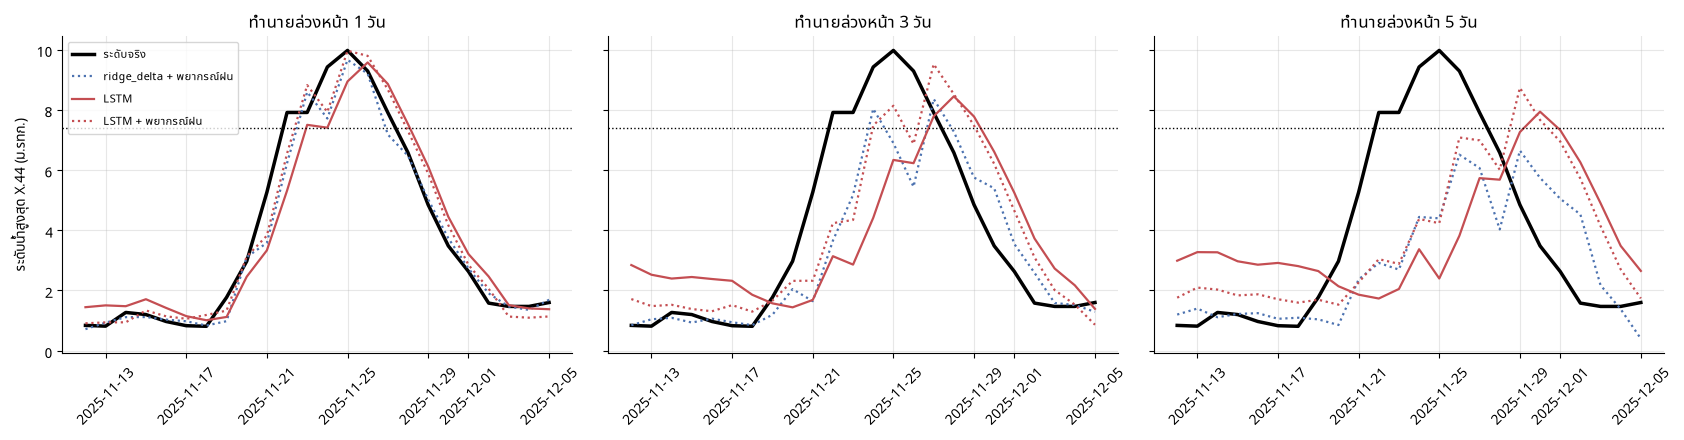

In [6]:
event = slice("2025-11-12", "2025-12-05")
actual = table["x44_max"].loc[event]
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), sharey=True)
for ax, h in zip(axes, (1, 3, 5)):
    ax.plot(actual.index, actual, color="k", lw=2.5, label="ระดับจริง")
    for name in ["ridge_delta + พยากรณ์ฝน", "LSTM", "LSTM + พยากรณ์ฝน"]:
        shifted = predictions[(name, h)].copy()
        shifted.index = shifted.index + pandas.Timedelta(days=h)
        ax.plot(shifted.loc[event], color=COLORS[name], ls=":" if "พยากรณ์ฝน" in name else "-", lw=1.6, label=name)
    ax.axhline(evaluation.FLOOD_M, color="k", ls=":", lw=1)
    ax.set_title(f"ทำนายล่วงหน้า {h} วัน")
    ax.tick_params(axis="x", rotation=45)
axes[0].set_ylabel("ระดับน้ำสูงสุด X.44 (ม.รทก.)")
axes[0].legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

## 3 · ความแกว่งระหว่าง seed
LSTM ที่ข้อมูลน้อยมักให้ผลต่างกันมากตาม seed — ดูว่า ensemble 5 seed ช่วยแค่ไหน

In [7]:
row = BEST["LSTM + พยากรณ์ฝน"]
params = {"hidden": int(row.hidden), "dropout": row.dropout, "lr": row.lr, "high_water_weight": row.high_water_weight}
single = []
for seed in SEEDS:
    prediction, _, _ = lstm_ensemble(params, RAIN, oracle_table, train_validation_days, test_days, int(row.epochs), seeds=[seed])
    single.append({f"h={h}": evaluation.scores(prediction[f"h{h}"].reindex(test_days), test, h)["MAE วันน้ำหลาก"] for h in HORIZONS})
single = pandas.DataFrame(single, index=[f"seed {s}" for s in SEEDS])
single.loc["ensemble 5 seed"] = [results.query("model == 'LSTM + พยากรณ์ฝน' and h == @h")["MAE วันน้ำหลาก"].iloc[0] for h in HORIZONS]
single.round(2).rename_axis(columns="LSTM + พยากรณ์ฝน · MAE วันน้ำหลาก (ม.)")

LSTM + พยากรณ์ฝน · MAE วันน้ำหลาก (ม.),h=1,h=2,h=3,h=4,h=5
seed 0,0.94,1.72,2.59,3.29,3.64
seed 1,0.89,1.54,2.49,3.08,3.40
seed 2,0.89,1.47,2.57,3.26,3.59
seed 3,0.98,1.66,2.44,3.07,3.30
seed 4,0.95,1.53,2.45,3.09,3.44
ensemble 5 seed,0.92,1.58,2.51,3.16,3.47


## 4 · สรุปเทียบกับตารางที่ 1 ในข้อเสนอโครงงาน

In [8]:
by_model = {metric: results.pivot(index="model", columns="h", values=metric)
            for metric in ["MAE วันน้ำหลาก", "เตือนถูก", "เตือนผิด"]}
summary = pandas.DataFrame({
    "MAE วันน้ำหลาก h=1": by_model["MAE วันน้ำหลาก"][1],
    "MAE วันน้ำหลาก h=3": by_model["MAE วันน้ำหลาก"][3],
    "MAE วันน้ำหลาก h=5": by_model["MAE วันน้ำหลาก"][5],
    "เตือนถูก h=1/2/3 (จาก 6)": by_model["เตือนถูก"][[1, 2, 3]].astype(int).astype(str).agg("/".join, axis=1),
    "เตือนผิดรวม h=1–5": by_model["เตือนผิด"].sum(axis=1).astype(int),
    "เวลาเทรน (วินาที)": pandas.Series(train_seconds),
}).loc[[name for name in ORDER if name != "persistence"]]
summary.round(2)

,MAE วันน้ำหลาก h=1,MAE วันน้ำหลาก h=3,MAE วันน้ำหลาก h=5,เตือนถูก h=1/2/3 (จาก 6),เตือนผิดรวม h=1–5,เวลาเทรน (วินาที)
ridge_delta,0.68,3.06,4.73,4/3/0,1,0.06
lgbm_delta,0.86,3.36,5.18,5/4/0,2,0.41
LSTM,1.27,3.34,4.45,5/2/1,6,3.23
ridge_delta + พยากรณ์ฝน,0.80,2.33,3.63,4/4/2,1,0.05
lgbm_delta + พยากรณ์ฝน,1.10,2.51,3.80,5/4/2,4,0.43
LSTM + พยากรณ์ฝน,0.92,2.51,3.47,5/4/3,7,6.30


### สรุป

**ข้อสันนิษฐานในข้อเสนอ ("LSTM จับ lag time ได้ดีกว่า") ไม่เป็นจริงกับข้อมูลชุดนี้ — ภาพรวม LSTM ไม่ชนะ Ridge**

| | ล่วงหน้า 1–2 วัน | ล่วงหน้า 3–5 วัน | วันปกติ | เตือนผิด |
|---|---|---|---|---|
| **Ridge + พยากรณ์ฝน** | ดี (0.80 / 1.47 ม.) | ดีที่ h=3–4 | ดีที่สุด | น้อยที่สุด (1) |
| **LSTM + พยากรณ์ฝน** | พอใช้ (0.92 / 1.58 ม.) | ดีที่สุดที่ h=5 (3.47 ม.), เตือน h=3 ได้ 3/6 | แกว่งกว่า (MAE ทุกวัน 0.15–0.41) | มากกว่า (7) |
| **LSTM (ไม่มีฝน)** | แย่กว่า Ridge ชัดเจน (1.27 ม. ที่ h=1) | ใกล้เคียง persistence | แย่ที่สุด (0.20–0.54) | 6 |

- **ทำไม LSTM ไม่ได้เปรียบ:** ข้อมูลรายวันมีแค่ ~1,400 ลำดับ และวันน้ำหลากใน train มีไม่กี่วัน → overfit ภายใน 15–22 epoch
  feature แบบ lag/การเปลี่ยนแปลงที่ทำไว้แล้ว (x173a_change_1d ฯลฯ) ก็ให้ข้อมูล lag time แก่ Ridge ไปแล้ว LSTM จึงไม่มีอะไรเพิ่ม
- **จุดที่ LSTM ดีกว่า:** ล่วงหน้าไกล (h=4–5) และจับยอดน้ำได้สูงกว่าในเหตุการณ์ 2568 แต่แลกกับการเตือนผิดที่มากขึ้นและวันปกติที่แกว่ง
- **ensemble 5 seed** ลดความแกว่ง: seed เดี่ยวให้ MAE h=5 ระหว่าง 3.30–3.64 ม.
- **เวลาเทรน:** ทุกโมเดลเร็วบน CPU — Ridge < 0.1 วินาที, LightGBM < 0.5 วินาที, LSTM 5 seed ~3–6 วินาที
  (ข้อเสนอคาดว่าต้องใช้ GPU — ไม่จำเป็นสำหรับข้อมูลรายวันขนาดนี้)

**ตัดสินใจ:** หน้าเว็บยังใช้ **Ridge + พยากรณ์ฝน** เป็นโมเดลหลัก (แม่นช่วงสั้น เตือนผิดน้อย อธิบายได้)
LSTM เก็บไว้เป็นผลเปรียบเทียบในรายงาน

**ถ้าจะให้ LSTM ได้เปรียบ:** ใช้ข้อมูลรายชั่วโมง (ลำดับยาวขึ้น ~24 เท่า), ขยายชุด train ด้วยเหตุการณ์ในอดีต (ERA5 + GloFAS 1997–2019),
หรือรวมหลายสถานีเป็น multi-task เพื่อให้เห็นเหตุการณ์น้ำขึ้นมากขึ้น